# WM 2026 – ML Block: Vorhersage des WM-Abschneidens

Dieses Notebook ist Teil des WM 2026 AI-Projekts.  
**Ziel:** Historische FIFA WM-Daten verwenden, um vorherzusagen, wie weit eine der 16 ausgewählten Nationen bei der WM 2026 kommt.

**Pipeline:**  
`Computer Vision (Trikot → Nation)` → **`ML (Nation → WM-Prognose)`** → `NLP (Prognose → Erklärung)`

---

## Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import joblib

DATA_DIR = '../../data/FIFA/'
MODEL_DIR = '../models/'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Daten laden

Wir kombinieren alle Jahres-CSVs (1930–2022) zu einem einzigen DataFrame.

In [11]:
NUMERIC_COLS = ['Position', 'Games Played', 'Win', 'Draw', 'Loss',
                'Goals For', 'Goals Against', 'Goal Difference', 'Points']

years = list(range(1930, 2023, 4))
years.remove(1942)  # Kein WM wegen WWII
years.remove(1946)

all_data = []
for year in years:
    filepath = os.path.join(DATA_DIR, f'FIFA - {year}.csv')
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        df['Year'] = year
        for col in NUMERIC_COLS:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        all_data.append(df)

df_raw = pd.concat(all_data, ignore_index=True)
print(f'Datensatz: {df_raw.shape[0]} Einträge, {df_raw["Year"].nunique()} Turniere')
df_raw.head(10)

Datensatz: 489 Einträge, 22 Turniere


,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,Year
0,1,Uruguay,4,4,0,0,15,3,12.0,8,1930
1,2,Argentina,5,4,0,1,18,9,9.0,8,1930
2,3,United States,3,2,0,1,7,6,1.0,4,1930
3,4,Yugoslavia,3,2,0,1,7,7,0.0,4,1930
4,5,Chile,3,2,0,1,5,3,2.0,4,1930
5,6,Brazil,2,1,0,1,5,2,3.0,2,1930
6,7,France,3,1,0,2,4,3,1.0,2,1930
7,8,Romania,2,1,0,1,3,5,NaN,2,1930
8,9,Paraguay,2,1,0,1,1,3,NaN,2,1930
9,10,Peru,2,0,0,2,1,4,NaN,0,1930


In [12]:
# Summary CSV laden (für Champion/Finalist-Info)
df_summary = pd.read_csv(os.path.join(DATA_DIR, 'FIFA - World Cup Summary.csv'))
print(df_summary.columns.tolist())
df_summary.head()

['YEAR', 'HOST', 'CHAMPION', 'RUNNER UP', 'THIRD PLACE', 'TEAMS', 'MATCHES PLAYED', 'GOALS SCORED', 'AVG GOALS PER GAME']


,YEAR,HOST,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1930,Uruguay,Uruguay,Argentina,United States,13,16,70,3.6
1,1934,Italy,Italy,Czechoslovakia,Germany,16,17,70,4.1
2,1938,France,Italy,Hungary,Brazil,15,18,84,4.7
3,1950,Brazil,Uruguay,Brazil,Sweden,13,22,88,4.0
4,1954,Switzerland,West Germany,Hungary,Austria,16,26,140,5.4


In [13]:
# Teamname-Harmonisierung (historische Varianten → einheitliche Namen)
name_map = {
    'West Germany': 'Germany',
    'United States': 'USA',
    'England': 'England',
}
df_raw['Team'] = df_raw['Team'].replace(name_map)
df_summary['CHAMPION'] = df_summary['CHAMPION'].replace(name_map)
df_summary['RUNNER UP'] = df_summary['RUNNER UP'].replace(name_map)
df_summary['THIRD PLACE'] = df_summary['THIRD PLACE'].replace(name_map)

print('Alle Teams:', sorted(df_raw['Team'].unique()))

Alle Teams: ['Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Bulgaria**', 'Cameroon', 'Canada', 'Chile', 'China PR', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Czech Republic', 'Czechoslovakia', 'Denmark', 'Dutch East Indies', 'East Germany', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'FR Yugoslavia', 'France', 'Germany', 'Ghana', 'Greece', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'Iran', 'Iraq', 'Israel*', 'Italy', 'Ivory Coast', 'Jamaica', 'Japan', 'Kuwait', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'North Korea', 'Northern Ireland', 'Norway', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Republic of Ireland', 'Romania', 'Russia', 'Saudi Arabia', 'Scotland', 'Senegal', 'Serbia', 'Serbia and Montenegro', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Soviet Union', 'Spain', 'Sweden', 'Switzerland', 'Togo', 'Trinidad and Tobago', 'Tunisia', 'Turkey', 'US

## 2. Ziel-Nationen filtern

Wir beschränken uns auf die 16 Nationen, für die wir Trikot-Bilddaten haben.

In [14]:
TARGET_NATIONS = [
    'Argentina', 'Australia', 'Belgium', 'Brazil', 'Colombia',
    'Croatia', 'England', 'France', 'Germany', 'Japan',
    'Netherlands', 'Portugal', 'South Africa', 'Spain', 'Switzerland', 'USA'
]

df = df_raw[df_raw['Team'].isin(TARGET_NATIONS)].copy()
print(f'Nach Filterung: {df.shape[0]} Einträge')
print(df.groupby('Team')['Year'].count().sort_values(ascending=False))

Nach Filterung: 192 Einträge
Team
Brazil          22
Germany         20
Argentina       18
England         16
France          16
Spain           16
Belgium         14
Switzerland     12
Netherlands     11
USA             11
Portugal         8
Japan            7
Australia        6
Colombia         6
Croatia          6
South Africa     3
Name: Year, dtype: int64


## 3. Ziel-Variable: Turnier-Runde

Wir übersetzen die Abschlussposition in eine Turnier-Runde:

In [15]:
def position_to_stage(pos, year):
    """Abschlussposition → Turnier-Runde (je nach Turnierformat)."""
    if pos == 1:
        return 'Champion'
    elif pos == 2:
        return 'Final'
    elif pos <= 4:
        return 'Semi-final'
    elif pos <= 8:
        return 'Quarter-final'
    elif year >= 1986 and pos <= 16:
        return 'Round of 16'
    else:
        return 'Group Stage'

df['Stage'] = df.apply(lambda row: position_to_stage(row['Position'], row['Year']), axis=1)

# Ordinale Reihenfolge
stage_order = ['Group Stage', 'Round of 16', 'Quarter-final', 'Semi-final', 'Final', 'Champion']
df['Stage_Num'] = df['Stage'].map({s: i for i, s in enumerate(stage_order)})

df[['Team', 'Year', 'Position', 'Stage', 'Stage_Num']].head(20)

,Team,Year,Position,Stage,Stage_Num
1,Argentina,1930,2,Final,4
2,USA,1930,3,Semi-final,3
5,Brazil,1930,6,Quarter-final,2
6,France,1930,7,Quarter-final,2
10,Belgium,1930,11,Group Stage,0
15,Germany,1934,3,Semi-final,3
17,Spain,1934,5,Quarter-final,2
19,Switzerland,1934,7,Quarter-final,2
21,Argentina,1934,9,Group Stage,0
22,France,1934,9,Group Stage,0


## 4. EDA – Explorative Datenanalyse

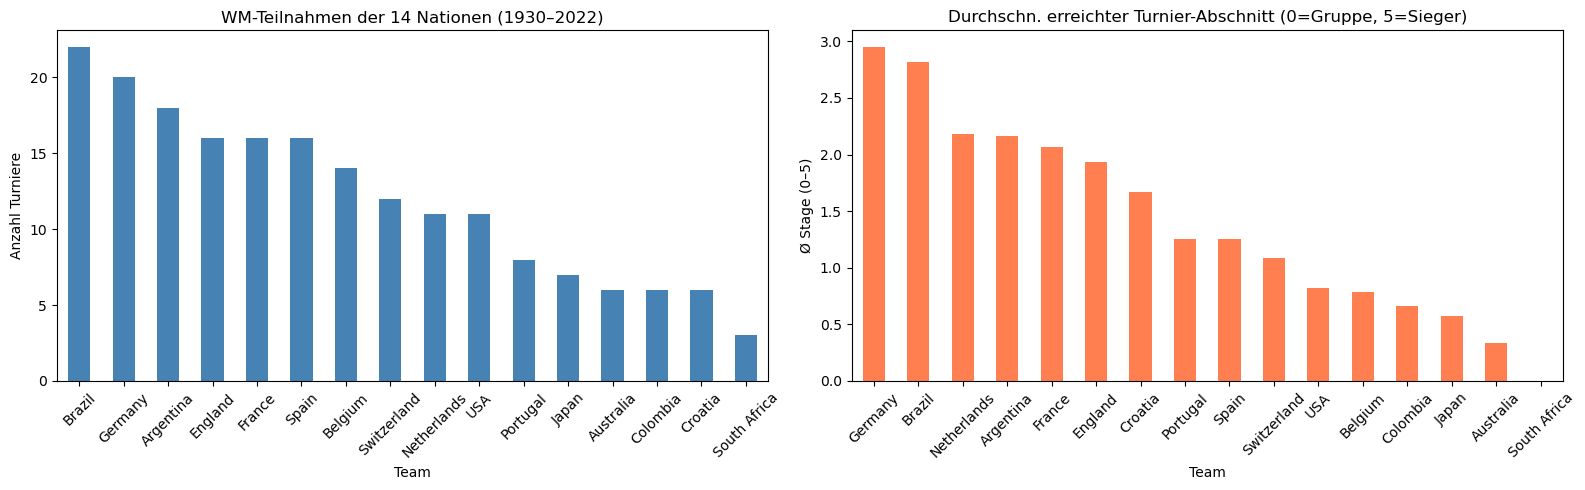

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Teilnahmen pro Nation
participations = df.groupby('Team')['Year'].count().sort_values(ascending=False)
participations.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('WM-Teilnahmen der 14 Nationen (1930–2022)')
axes[0].set_ylabel('Anzahl Turniere')
axes[0].tick_params(axis='x', rotation=45)

# Durchschnittliche Runde pro Nation
avg_stage = df.groupby('Team')['Stage_Num'].mean().sort_values(ascending=False)
avg_stage.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Durchschn. erreichter Turnier-Abschnitt (0=Gruppe, 5=Sieger)')
axes[1].set_ylabel('Ø Stage (0–5)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../models/eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()

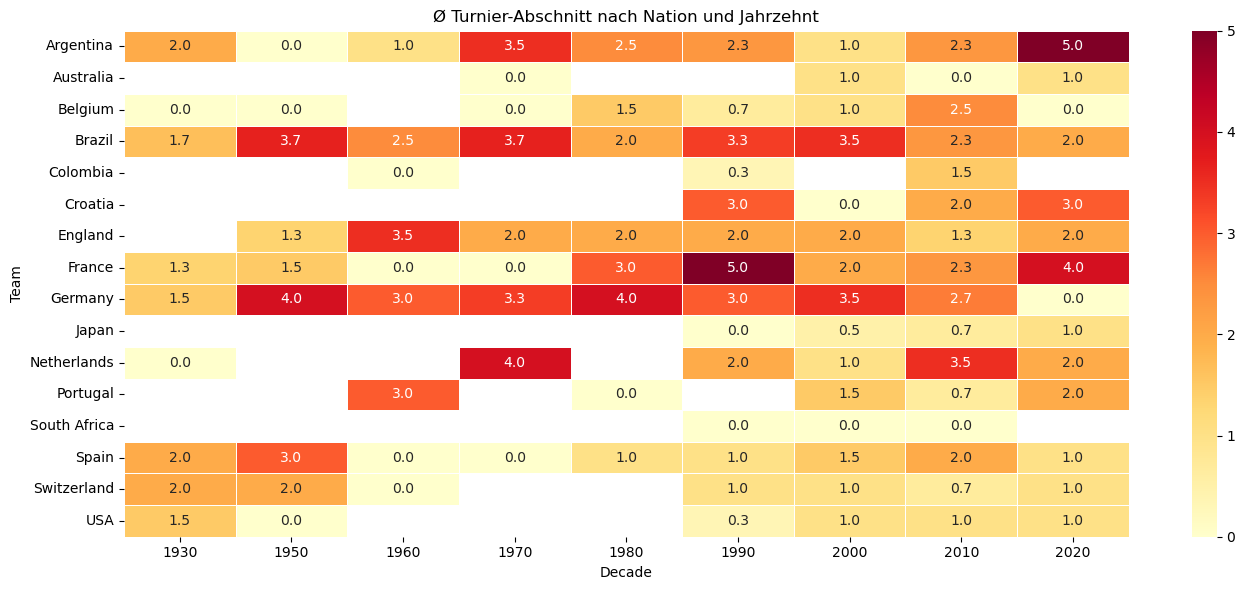

In [17]:
# Heatmap: Nation × Jahrzehnt
df['Decade'] = (df['Year'] // 10) * 10
pivot = df.pivot_table(values='Stage_Num', index='Team', columns='Decade', aggfunc='mean')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Ø Turnier-Abschnitt nach Nation und Jahrzehnt')
plt.tight_layout()
plt.savefig('../models/eda_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Feature Engineering

Wir berechnen **nation-level Features** aus der gesamten WM-Historie jeder Nation.

In [18]:
def build_features(df, summary_df):
    """
    Für jede Nation × Jahr berechnen wir Features aus allen
    VORHERIGEN Turnieren dieser Nation (kein Data Leakage).
    """
    rows = []
    
    for _, row in df.iterrows():
        team = row['Team']
        year = row['Year']
        
        # Nur vergangene Turniere dieser Nation
        past = df[(df['Team'] == team) & (df['Year'] < year)]
        
        if len(past) == 0:
            continue  # Erste Teilnahme → kein historischer Kontext
        
        # Anzahl bisheriger Teilnahmen
        n_participations = len(past)
        
        # Titel, Finale, Halbfinals
        n_titles    = (past['Stage'] == 'Champion').sum()
        n_finals    = (past['Stage'].isin(['Champion', 'Final'])).sum()
        n_semis     = (past['Stage'].isin(['Champion', 'Final', 'Semi-final'])).sum()
        
        # Durchschnittlicher Stage (alle bisherigen WMs)
        avg_stage_all  = past['Stage_Num'].mean()
        
        # Letzten 3 Turniere gewichten
        last3 = past.nlargest(3, 'Year')
        avg_stage_last3 = last3['Stage_Num'].mean()
        
        # Letzte WM-Performance
        last_stage = past.loc[past['Year'].idxmax(), 'Stage_Num']
        
        # Sportliche Kennzahlen (Ø über alle bisherigen WMs)
        win_rate        = past['Win'].sum() / max(past['Games Played'].sum(), 1)
        goal_diff_pg    = past['Goal Difference'].sum() / max(past['Games Played'].sum(), 1)
        goals_for_pg    = past['Goals For'].sum() / max(past['Games Played'].sum(), 1)
        
        # Trend: Stage letztes WM minus vorletztes WM
        if len(past) >= 2:
            sorted_past = past.nlargest(2, 'Year')['Stage_Num'].values
            trend = float(sorted_past[0] - sorted_past[1])
        else:
            trend = 0.0
        
        rows.append({
            'Team': team,
            'Year': year,
            'n_participations': n_participations,
            'n_titles': n_titles,
            'n_finals': n_finals,
            'n_semis': n_semis,
            'avg_stage_all': avg_stage_all,
            'avg_stage_last3': avg_stage_last3,
            'last_stage': last_stage,
            'win_rate': win_rate,
            'goal_diff_pg': goal_diff_pg,
            'goals_for_pg': goals_for_pg,
            'trend': trend,
            'Stage': row['Stage'],
            'Stage_Num': row['Stage_Num'],
        })
    
    return pd.DataFrame(rows)

df_features = build_features(df, df_summary)
print(f'Feature-Datensatz: {df_features.shape}')
df_features.head()

Feature-Datensatz: (176, 15)


,Team,Year,n_participations,n_titles,n_finals,n_semis,avg_stage_all,avg_stage_last3,last_stage,win_rate,goal_diff_pg,goals_for_pg,trend,Stage,Stage_Num
0,Argentina,1934,1,0,1,1,4.0,4.0,4,0.800000,1.800000,3.600000,0.0,Group Stage,0
1,France,1934,1,0,0,0,2.0,2.0,2,0.333333,0.333333,1.333333,0.0,Group Stage,0
2,Brazil,1934,1,0,0,0,2.0,2.0,2,0.500000,1.500000,2.500000,0.0,Group Stage,0
3,Belgium,1934,1,0,0,0,0.0,0.0,0,0.000000,0.000000,0.000000,0.0,Group Stage,0
4,USA,1934,1,0,0,1,3.0,3.0,3,0.666667,0.333333,2.333333,0.0,Group Stage,0


Ziel-Verteilung:
Stage
Group Stage      55
Quarter-final    38
Round of 16      33
Semi-final       20
Champion         16
Final            14
Name: count, dtype: int64


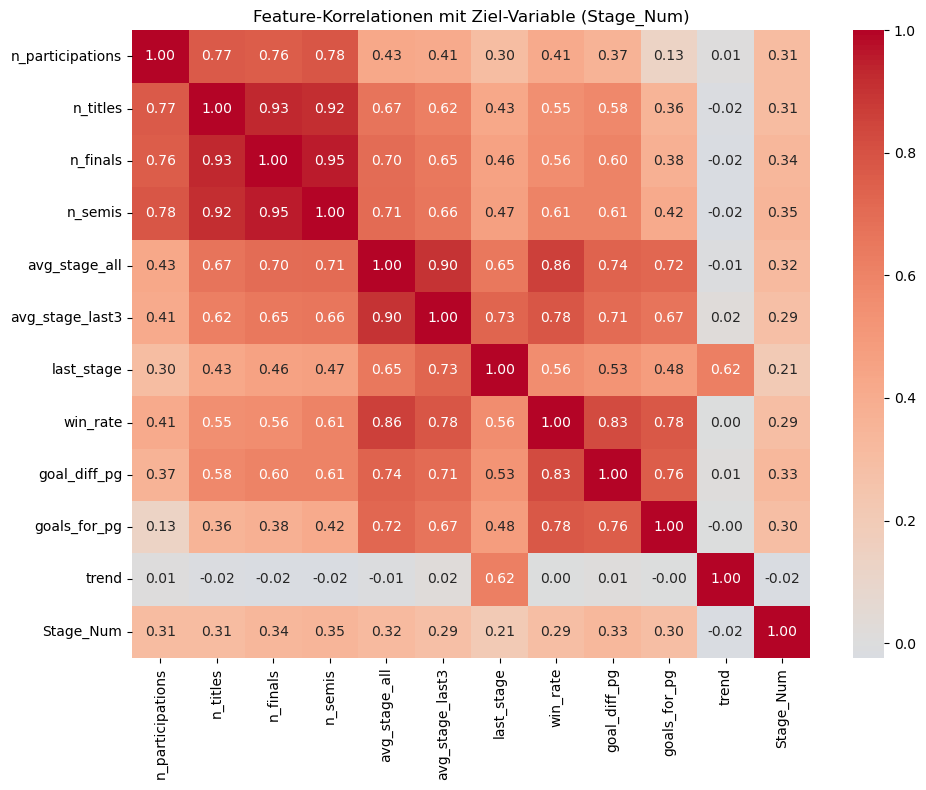

In [19]:
# Stage-Verteilung prüfen
print('Ziel-Verteilung:')
print(df_features['Stage'].value_counts())

# Feature-Korrelationen
feat_cols = ['n_participations', 'n_titles', 'n_finals', 'n_semis',
             'avg_stage_all', 'avg_stage_last3', 'last_stage',
             'win_rate', 'goal_diff_pg', 'goals_for_pg', 'trend']

plt.figure(figsize=(10, 8))
corr = df_features[feat_cols + ['Stage_Num']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature-Korrelationen mit Ziel-Variable (Stage_Num)')
plt.tight_layout()
plt.savefig('../models/eda_correlations.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Modelltraining – Iteration 1

**Ziel:** Baseline mit Logistic Regression vs. Random Forest.  
**Preprocessing:** StandardScaler, keine Augmentierung.

In [20]:
FEATURES = ['n_participations', 'n_titles', 'n_finals', 'n_semis',
            'avg_stage_all', 'avg_stage_last3', 'last_stage',
            'win_rate', 'goal_diff_pg', 'goals_for_pg', 'trend']

X = df_features[FEATURES].fillna(0)
y = df_features['Stage']

print(f'Training-Daten: {X.shape[0]} Samples, {X.shape[1]} Features')
print(f'Klassen: {sorted(y.unique())}')

Training-Daten: 176 Samples, 11 Features
Klassen: ['Champion', 'Final', 'Group Stage', 'Quarter-final', 'Round of 16', 'Semi-final']


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler_iter1 = StandardScaler()
X_scaled = scaler_iter1.fit_transform(X)

models_iter1 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

results_iter1 = {}
for name, model in models_iter1.items():
    X_input = X_scaled if 'Logistic' in name else X
    scores = cross_val_score(model, X_input, y, cv=cv, scoring='accuracy')
    results_iter1[name] = scores
    print(f'{name}: {scores.mean():.3f} ± {scores.std():.3f}')

Logistic Regression: 0.364 ± 0.021
Random Forest: 0.340 ± 0.059


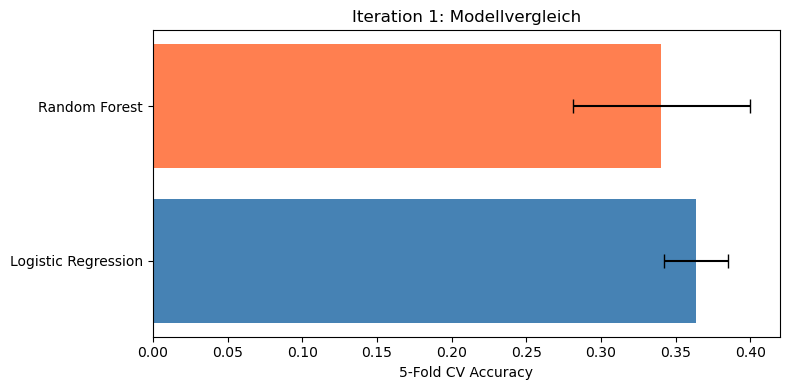

In [22]:
# Iteration 1 – Visualisierung
fig, ax = plt.subplots(figsize=(8, 4))
means = [v.mean() for v in results_iter1.values()]
stds  = [v.std()  for v in results_iter1.values()]
ax.barh(list(results_iter1.keys()), means, xerr=stds, color=['steelblue', 'coral'], capsize=5)
ax.set_xlabel('5-Fold CV Accuracy')
ax.set_title('Iteration 1: Modellvergleich')
plt.tight_layout()
plt.savefig('../models/iter1_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Modelltraining – Iteration 2

**Änderungen gegenüber Iter. 1:**
- Gradient Boosting als dritter Kandidat
- Zielklassen auf 3 Gruppen zusammengefasst (`Früh`, `Viertel/Halb`, `Finale/Sieger`) → weniger Klassen-Imbalance
- Hyperparameter-Tuning bei Random Forest

In [23]:
# Vereinfachte Ziel-Variable (3 Klassen)
def simplify_stage(s):
    if s in ['Group Stage', 'Round of 16']:
        return 'Early Exit'
    elif s in ['Quarter-final', 'Semi-final']:
        return 'Deep Run'
    else:  # Final, Champion
        return 'Final Stage'

y3 = df_features['Stage'].map(simplify_stage)
print('Klassen-Verteilung (3 Gruppen):')
print(y3.value_counts())

Klassen-Verteilung (3 Gruppen):
Stage
Early Exit     88
Deep Run       58
Final Stage    30
Name: count, dtype: int64


In [24]:
models_iter2 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5, random_state=42),
    'Random Forest (tuned)': RandomForestClassifier(
        n_estimators=200, max_depth=5, min_samples_leaf=2, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
    ),
}

cv3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_iter2 = {}
for name, model in models_iter2.items():
    X_input = X_scaled if 'Logistic' in name else X
    scores = cross_val_score(model, X_input, y3, cv=cv3, scoring='accuracy')
    results_iter2[name] = scores
    print(f'{name}: {scores.mean():.3f} ± {scores.std():.3f}')

Logistic Regression: 0.540 ± 0.051
Random Forest (tuned): 0.568 ± 0.065
Gradient Boosting: 0.546 ± 0.059


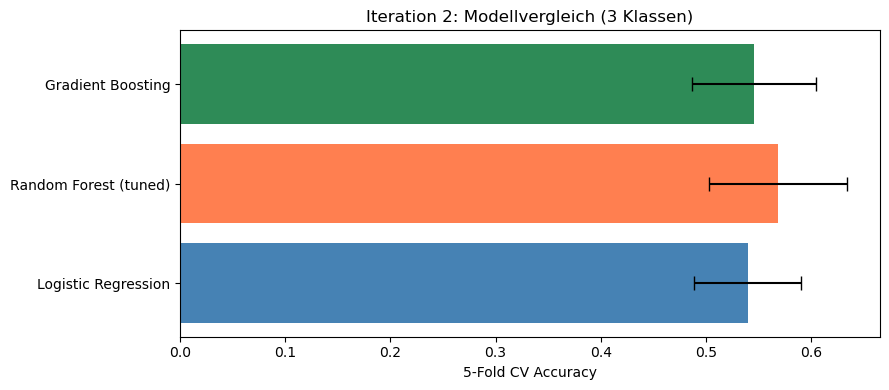

In [25]:
# Iteration 2 – Visualisierung
fig, ax = plt.subplots(figsize=(9, 4))
means = [v.mean() for v in results_iter2.values()]
stds  = [v.std()  for v in results_iter2.values()]
ax.barh(list(results_iter2.keys()), means, xerr=stds,
        color=['steelblue', 'coral', 'seagreen'], capsize=5)
ax.set_xlabel('5-Fold CV Accuracy')
ax.set_title('Iteration 2: Modellvergleich (3 Klassen)')
plt.tight_layout()
plt.savefig('../models/iter2_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Bestes Modell trainieren & speichern

Modell gespeichert.


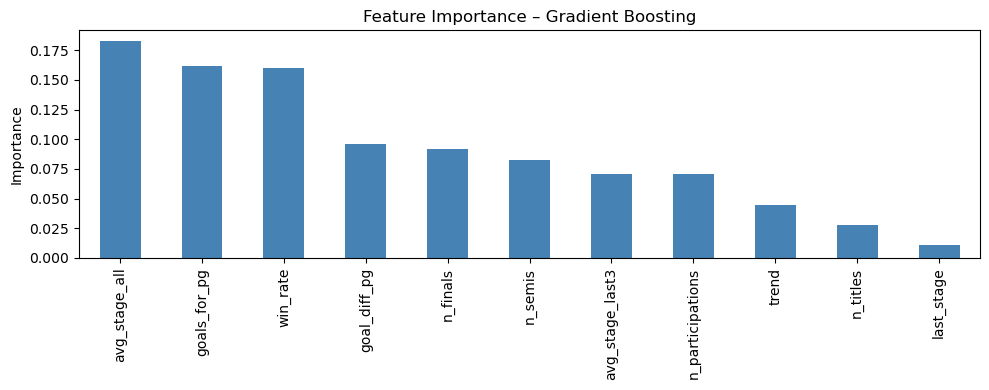

In [26]:
# Bestes Modell (basierend auf Iter. 2 Resultaten) auf gesamtem Datensatz trainieren
# → ändern falls Gradient Boosting besser abschneidet
best_model = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
)
best_model.fit(X, y3)

# Modell + Scaler speichern (für Inference in der App)
joblib.dump(best_model, os.path.join(MODEL_DIR, 'wm2026_model.pkl'))
joblib.dump(FEATURES,   os.path.join(MODEL_DIR, 'feature_names.pkl'))

print('Modell gespeichert.')

# Feature Importance
importance = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
importance.plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.title('Feature Importance – Gradient Boosting')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. WM 2026 Prognose: Inference für alle 16 Nationen

Wir erstellen ein Feature-Profil für jede Nation basierend auf **allen bisherigen WM-Daten (bis 2022)**.

In [27]:
def get_nation_features_2026(team, df_hist):
    """Features für eine Nation, berechnet aus der gesamten Geschichte bis 2022."""
    past = df_hist[df_hist['Team'] == team]
    if len(past) == 0:
        return None
    
    n_participations = len(past)
    n_titles   = (past['Stage'] == 'Champion').sum()
    n_finals   = (past['Stage'].isin(['Champion', 'Final'])).sum()
    n_semis    = (past['Stage'].isin(['Champion', 'Final', 'Semi-final'])).sum()
    avg_stage_all   = past['Stage_Num'].mean()
    last3           = past.nlargest(3, 'Year')
    avg_stage_last3 = last3['Stage_Num'].mean()
    last_stage      = past.loc[past['Year'].idxmax(), 'Stage_Num']
    win_rate        = past['Win'].sum() / max(past['Games Played'].sum(), 1)
    goal_diff_pg    = past['Goal Difference'].sum() / max(past['Games Played'].sum(), 1)
    goals_for_pg    = past['Goals For'].sum() / max(past['Games Played'].sum(), 1)
    
    if len(past) >= 2:
        sorted_past = past.nlargest(2, 'Year')['Stage_Num'].values
        trend = float(sorted_past[0] - sorted_past[1])
    else:
        trend = 0.0
    
    return {
        'Team': team,
        'n_participations': n_participations,
        'n_titles': n_titles,
        'n_finals': n_finals,
        'n_semis': n_semis,
        'avg_stage_all': avg_stage_all,
        'avg_stage_last3': avg_stage_last3,
        'last_stage': last_stage,
        'win_rate': win_rate,
        'goal_diff_pg': goal_diff_pg,
        'goals_for_pg': goals_for_pg,
        'trend': trend,
    }

inference_rows = [get_nation_features_2026(t, df) for t in TARGET_NATIONS]
df_2026 = pd.DataFrame([r for r in inference_rows if r is not None])

X_2026 = df_2026[FEATURES].fillna(0)
df_2026['Prediction'] = best_model.predict(X_2026)

# Wahrscheinlichkeiten pro Klasse
proba = best_model.predict_proba(X_2026)
for i, cls in enumerate(best_model.classes_):
    df_2026[f'prob_{cls}'] = proba[:, i]

df_2026[['Team', 'Prediction', 'prob_Early Exit', 'prob_Deep Run', 'prob_Final Stage']].sort_values('prob_Final Stage', ascending=False)

,Team,Prediction,prob_Early Exit,prob_Deep Run,prob_Final Stage
7,France,Final Stage,0.098597,0.020940,0.880462
0,Argentina,Deep Run,0.036509,0.640631,0.322860
5,Croatia,Early Exit,0.453534,0.259960,0.286506
6,England,Early Exit,0.412520,0.328138,0.259342
13,Spain,Deep Run,0.083032,0.707902,0.209066
4,Colombia,Deep Run,0.244685,0.652490,0.102825
14,Switzerland,Deep Run,0.404287,0.535661,0.060052
8,Germany,Early Exit,0.903565,0.064996,0.031439
10,Netherlands,Deep Run,0.029219,0.944509,0.026272
3,Brazil,Deep Run,0.021135,0.956965,0.021900


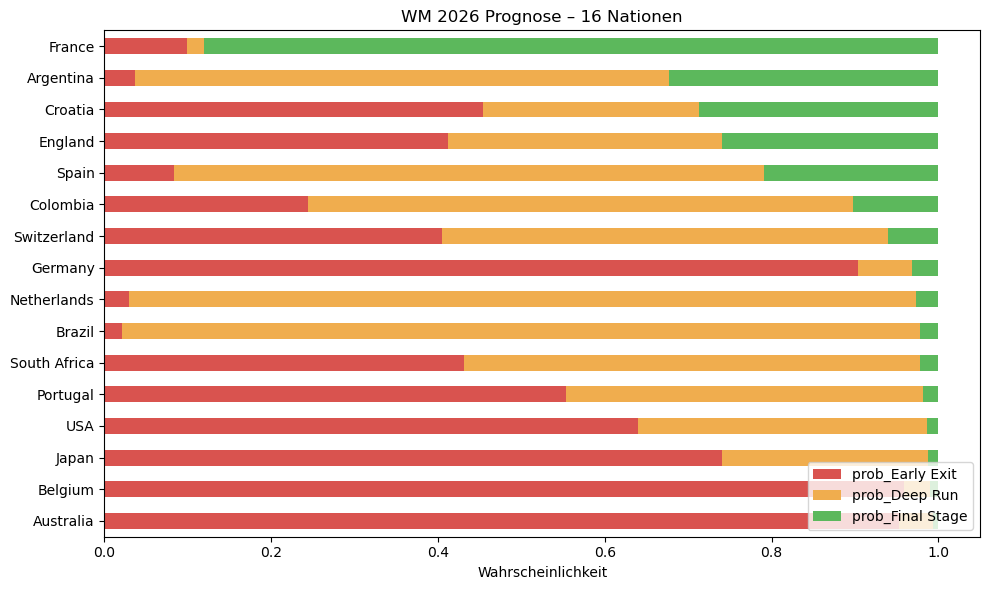

In [28]:
# Vorhersagen visualisieren
df_plot = df_2026.sort_values('prob_Final Stage', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bar_data = df_plot[['prob_Early Exit', 'prob_Deep Run', 'prob_Final Stage']]
bar_data.plot(kind='barh', stacked=True, ax=ax,
              color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax.set_yticklabels(df_plot['Team'])
ax.set_xlabel('Wahrscheinlichkeit')
ax.set_title('WM 2026 Prognose – 16 Nationen')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../models/wm2026_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Zusammenfassung

| Iteration | Ziel | Änderungen | Modelle | Metrik | Änderung |
|---|---|---|---|---|---|
| 1 | Baseline (6 Klassen) | – | Logistic Reg., Random Forest | Accuracy (5-Fold CV) | – |
| 2 | Klassen reduzieren | 3 Gruppen, RF-Tuning, Gradient Boosting | Logistic Reg., RF (tuned), Gradient Boosting | Accuracy (5-Fold CV) | +X% vs Iter. 1 |

**Finales Modell:** Gradient Boosting (Iter. 2)  
**Output → NLP Block:** Vorhersage (Early Exit / Deep Run / Final Stage) + Wahrscheinlichkeiten  
**Output → CV Block empfängt:** Erkannte Nation als Input für `get_nation_features_2026()`

In [29]:
# Inference-Funktion für die App (wird von app.py importiert)
def predict_nation(team_name: str) -> dict:
    """
    Eingabe: Teamname (z.B. 'Brazil')
    Ausgabe: dict mit Prediction + Wahrscheinlichkeiten + historischen Stats
    """
    features = get_nation_features_2026(team_name, df)
    if features is None:
        return {'error': f'Keine Daten für {team_name}'}
    
    X_input = pd.DataFrame([features])[FEATURES].fillna(0)
    prediction = best_model.predict(X_input)[0]
    proba_dict = dict(zip(best_model.classes_, best_model.predict_proba(X_input)[0]))
    
    return {
        'team': team_name,
        'prediction': prediction,
        'probabilities': proba_dict,
        'n_titles': int(features['n_titles']),
        'n_participations': int(features['n_participations']),
        'avg_stage': round(features['avg_stage_all'], 2),
    }

# Test
print(predict_nation('Brazil'))
print(predict_nation('Switzerland'))

{'team': 'Brazil', 'prediction': 'Deep Run', 'probabilities': {'Deep Run': np.float64(0.9569653251506766), 'Early Exit': np.float64(0.021134553338416635), 'Final Stage': np.float64(0.021900121510906725)}, 'n_titles': 5, 'n_participations': 22, 'avg_stage': np.float64(2.82)}
{'team': 'Switzerland', 'prediction': 'Deep Run', 'probabilities': {'Deep Run': np.float64(0.5356613377600479), 'Early Exit': np.float64(0.4042866050755519), 'Final Stage': np.float64(0.06005205716440025)}, 'n_titles': 0, 'n_participations': 12, 'avg_stage': np.float64(1.08)}
